__Задание 2:__

Выберите 1 из 2-ух временных рядов из задания 1 и сделайте прогноз на ближайший месяц-квартал-полугодие  и год. Модель выбирать исходя из ваших предположений и умозаключений. Необходимо обосновать почему была выбрана та или иная модель и на каких основаниях, в чем она лучше и почему она подходит. Оценить качество прогноза согласно выбранной метрике, проверить качество на отложенной выборке путем применения TimeSeriesSplit. Сформировать отчет с выводами и визуализациями в jupyter notebook’e.




Анализ TS выполнялся на данных о стоимости акций Boeing

In [285]:
from mplfinance.original_flavor import candlestick_ohlc
import yfinance as yf  
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import requests
from datetime import datetime
import pandas as pd
import warnings
import numpy as np
import seaborn as sns

In [287]:
from dateutil.relativedelta import relativedelta # working with dates with style
from scipy.optimize import minimize              # for function minimization
import statsmodels.formula.api as smf            # statistics and econometrics
import statsmodels.tsa.api as smt
import statsmodels.api as sm
import scipy.stats as scs
from itertools import product
from tqdm import tqdm_notebook

sns.set()
%matplotlib inline
warnings.filterwarnings("ignore")

In [ ]:
Прогнозирование выполнялось с примененим методов ML. 
Была выбрана  линейная регрессия и бустинг из-за простоты и отсутствия необходимости дополнительной подготовки
SARIMA - не применяю, так как нет ярко выраженной сезонности


Добавляем лаги 
Сдвигая ряд на k шагов мы получаем столбец-признак, в котором текущему значению ряда в момент  t будет соответствовать его значение в момент времени t-n. Таким образом, если сделать отступ в 1 шаг, то модель, обученная на таком признаке, будет способна давать предсказание на 1 шаг вперед, зная текущее состояние ряда. 

In [289]:
data = pd.read_csv("D:/DS_2025/9/homework/BA.csv")

In [291]:
data.head()

,Дата,Цена,Откр.,Макс.,Мин.,Объём,Изм. %
0,22.04.2025,"159,86","162,13","162,97","158,61","5,95M","0,33%"
1,21.04.2025,"159,34","162,40","160,00","156,47","5,70M","-1,58%"
2,17.04.2025,"161,90","157,13","163,90","157,00","9,23M","3,47%"
3,16.04.2025,"156,47","154,37","157,66","153,54","6,81M","0,61%"
4,15.04.2025,"155,52","155,27","159,12","155,27","11,54M","-2,36%"


In [293]:
#переименуем столбцы
data = data.rename(columns= {'Дата':'Date', 'Откр.':'Open', 'Цена':'Close', 'Макс.':'High', 'Мин.': 'Low', 'Объём': 'Volume', 'Изм. %': 'delta'})

In [295]:
data.head(3)

,Date,Close,Open,High,Low,Volume,delta
0,22.04.2025,"159,86","162,13","162,97","158,61","5,95M","0,33%"
1,21.04.2025,"159,34","162,40","160,00","156,47","5,70M","-1,58%"
2,17.04.2025,"161,90","157,13","163,90","157,00","9,23M","3,47%"


In [297]:
# #Перевод в datetime object для работы с датой:
data['Date'] = pd.to_datetime(data['Date'])
data['Date'].head()

0   2025-04-22
1   2025-04-21
2   2025-04-17
3   2025-04-16
4   2025-04-15
Name: Date, dtype: datetime64[ns]

In [299]:
data = data.sort_values(['Date'])

In [301]:
data

,Date,Close,Open,High,Low,Volume,delta
1065,2021-01-25,"203,36","203,26","203,80","199,30","14,28M","-1,20%"
1064,2021-01-26,"202,06","205,34","208,35","201,79","11,01M","-0,64%"
1063,2021-01-27,"194,03","196,90","199,47","191,85","20,95M","-3,97%"
1062,2021-01-28,"197,23","198,04","200,42","196,00","10,40M","1,65%"
1061,2021-01-29,"194,19","198,30","201,57","193,12","13,68M","-1,54%"
...,...,...,...,...,...,...,...
4,2025-04-15,"155,52","155,27","159,12","155,27","11,54M","-2,36%"
3,2025-04-16,"156,47","154,37","157,66","153,54","6,81M","0,61%"
2,2025-04-17,"161,90","157,13","163,90","157,00","9,23M","3,47%"
1,2025-04-21,"159,34","162,40","160,00","156,47","5,70M","-1,58%"


In [303]:
data.shape

(1066, 7)

In [305]:
data.set_index('Date', inplace = True)

In [307]:
data

,Close,Open,High,Low,Volume,delta
Date,,,,,,
2021-01-25,"203,36","203,26","203,80","199,30","14,28M","-1,20%"
2021-01-26,"202,06","205,34","208,35","201,79","11,01M","-0,64%"
2021-01-27,"194,03","196,90","199,47","191,85","20,95M","-3,97%"
2021-01-28,"197,23","198,04","200,42","196,00","10,40M","1,65%"
2021-01-29,"194,19","198,30","201,57","193,12","13,68M","-1,54%"
...,...,...,...,...,...,...
2025-04-15,"155,52","155,27","159,12","155,27","11,54M","-2,36%"
2025-04-16,"156,47","154,37","157,66","153,54","6,81M","0,61%"
2025-04-17,"161,90","157,13","163,90","157,00","9,23M","3,47%"


Посмотрим на распределение целевого признака:

In [310]:
data = data.drop(['Volume'], axis=1)

In [312]:
data = data.drop(['delta'], axis=1)

In [314]:
data.head()

,Close,Open,High,Low
Date,,,,
2021-01-25,"203,36","203,26","203,80","199,30"
2021-01-26,"202,06","205,34","208,35","201,79"
2021-01-27,"194,03","196,90","199,47","191,85"
2021-01-28,"197,23","198,04","200,42","196,00"
2021-01-29,"194,19","198,30","201,57","193,12"


In [316]:
data['Close'] = data['Close'].str.replace(',', '.').astype(float)
data['Open'] = data['Open'].str.replace(',', '.').astype(float)
data['High'] = data['High'].str.replace(',', '.').astype(float)
data['Low'] = data['Low'].str.replace(',', '.').astype(float)





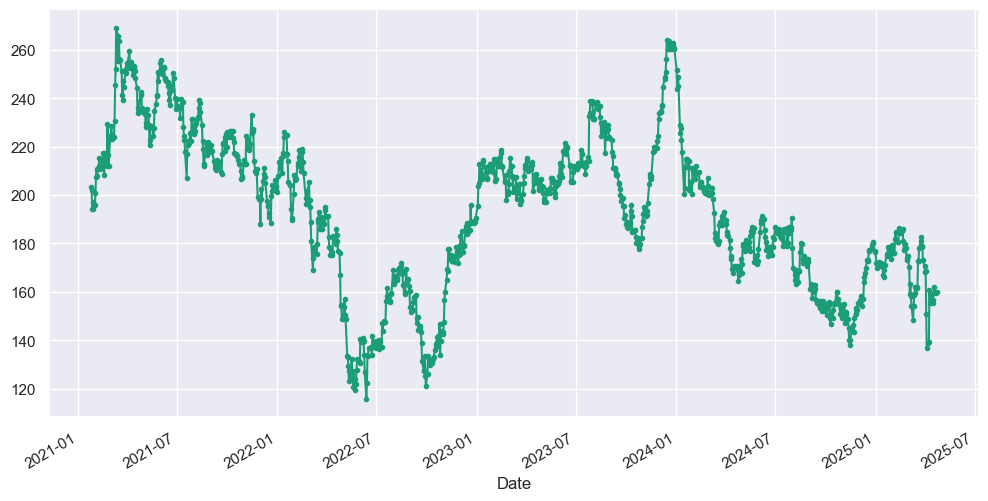

In [318]:
data['Close'].plot(figsize=(12,6), marker='o', markersize=3, cmap='Dark2')
plt.show()

In [320]:
# Добавим лаги временного ряда для целевой переменной начиная с 6 заканчивая 24
for i in range(6, 25):
    data["lag_{}".format(i)] = data.Close.shift(i)

In [322]:
data.tail()

,Close,Open,High,Low,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,...,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24
Date,,,,,,,,,,,,,,,,,,,,,
2025-04-15,155.52,155.27,159.12,155.27,138.86,136.59,150.91,168.56,168.17,170.55,...,182.59,180.90,178.11,172.83,172.62,161.57,161.85,161.81,159.32,158.80
2025-04-16,156.47,154.37,157.66,153.54,139.39,138.86,136.59,150.91,168.56,168.17,...,178.55,182.59,180.90,178.11,172.83,172.62,161.57,161.85,161.81,159.32
2025-04-17,161.90,157.13,163.90,157.00,160.82,139.39,138.86,136.59,150.91,168.56,...,179.11,178.55,182.59,180.90,178.11,172.83,172.62,161.57,161.85,161.81
2025-04-21,159.34,162.40,160.00,156.47,155.52,160.82,139.39,138.86,136.59,150.91,...,173.31,179.11,178.55,182.59,180.90,178.11,172.83,172.62,161.57,161.85
2025-04-22,159.86,162.13,162.97,158.61,156.84,155.52,160.82,139.39,138.86,136.59,...,170.55,173.31,179.11,178.55,182.59,180.90,178.11,172.83,172.62,161.57


In [324]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, TimeSeriesSplit

# 5 фолдов
tscv = TimeSeriesSplit(n_splits=5)

In [326]:
def timeseries_train_test_split(X, y, test_size):
    test_index = int(len(X)*(1-test_size))
    
    X_train = X.iloc[:test_index-1]
    y_train = y.iloc[:test_index-1]

    X_test = X.iloc[test_index:]
    y_test = y.iloc[test_index:]
    
    return X_train, X_test, y_train, y_test

In [328]:
y = data.dropna().Close
X = data.dropna().drop(['Close'], axis=1)

X_train, X_test, y_train, y_test = timeseries_train_test_split(X, y, test_size=0.3)

In [330]:
# реализовываем модель
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

Реализовываем функцию для расчета MAPE

In [338]:
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [340]:
def plotModelResults(model, X_train=X_train, X_test=X_test, plot_intervals=False, plot_anomalies=False):

    prediction = model.predict(X_test)
    
    plt.figure(figsize=(15, 7))
    plt.plot(prediction, "g", label="prediction", linewidth=2.0)
    plt.plot(y_test.values, label="actual", linewidth=2.0)
    
    if plot_intervals:
        cv = cross_val_score(model, X_train, y_train, 
                                    cv=tscv, 
                                    scoring="neg_mean_absolute_error")
        mae = cv.mean() * (-1)
        deviation = cv.std()
        
        scale = 1.96
        lower = prediction - (mae + scale * deviation)
        upper = prediction + (mae + scale * deviation)
        
        plt.plot(lower, "r--", label="upper bond / lower bond", alpha=0.5)
        plt.plot(upper, "r--", alpha=0.5)
        
        if plot_anomalies:
            anomalies = np.array([np.NaN]*len(y_test))
            anomalies[y_test<lower] = y_test[y_test<lower]
            anomalies[y_test>upper] = y_test[y_test>upper]
            plt.plot(anomalies, "o", markersize=10, label = "Anomalies")
    
    error = mean_absolute_percentage_error(prediction, y_test)
    plt.title("Mean absolute percentage error {0:.2f}%".format(error))
    plt.legend(loc="best")
    plt.tight_layout()
    plt.grid(True);
    plt.show()
    
def plotCoefficients(model):

    coefs = pd.DataFrame(model.coef_, X_train.columns)
    coefs.columns = ["coef"]
    coefs["abs"] = coefs.coef.apply(np.abs)
    coefs = coefs.sort_values(by="abs", ascending=False).drop(["abs"], axis=1)
    
    plt.figure(figsize=(15, 7))
    coefs.coef.plot(kind='bar')
    plt.grid(True, axis='y')
    plt.hlines(y=0, xmin=0, xmax=len(coefs), linestyles='dashed');
    plt.show()

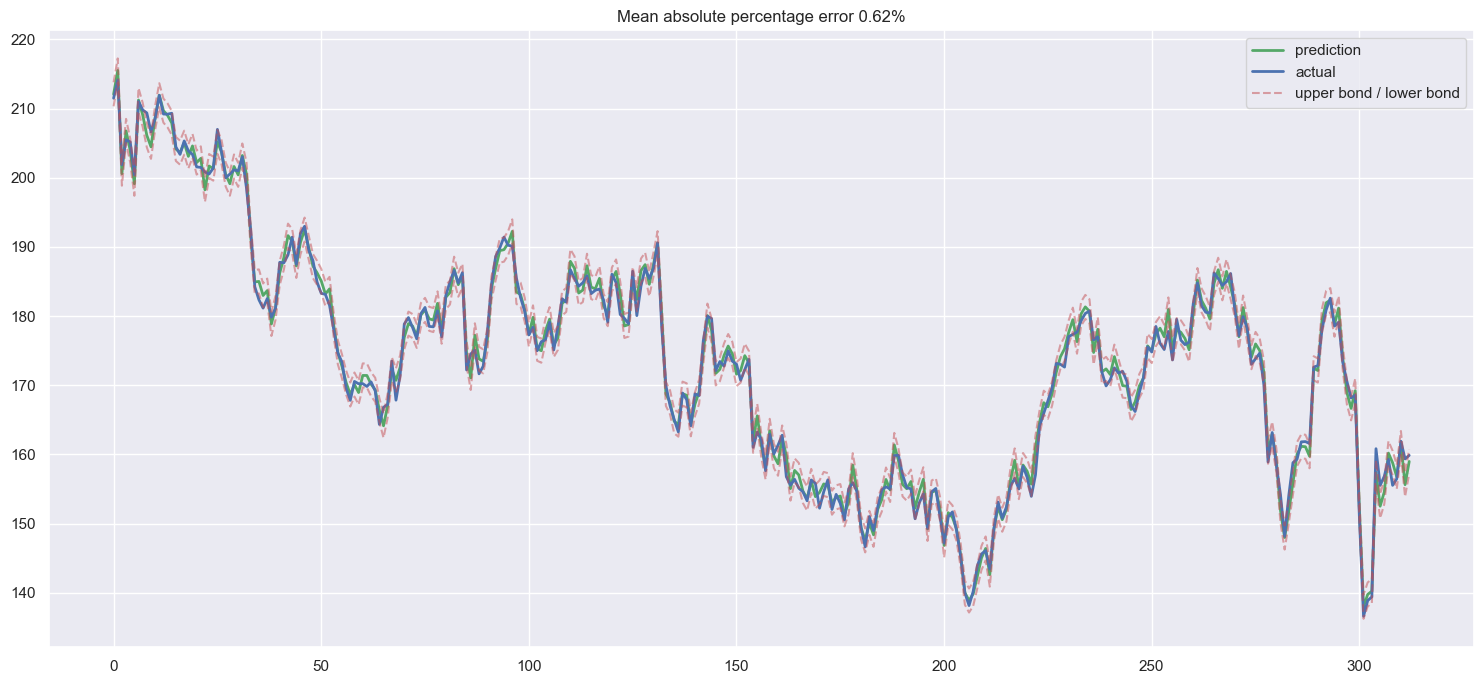

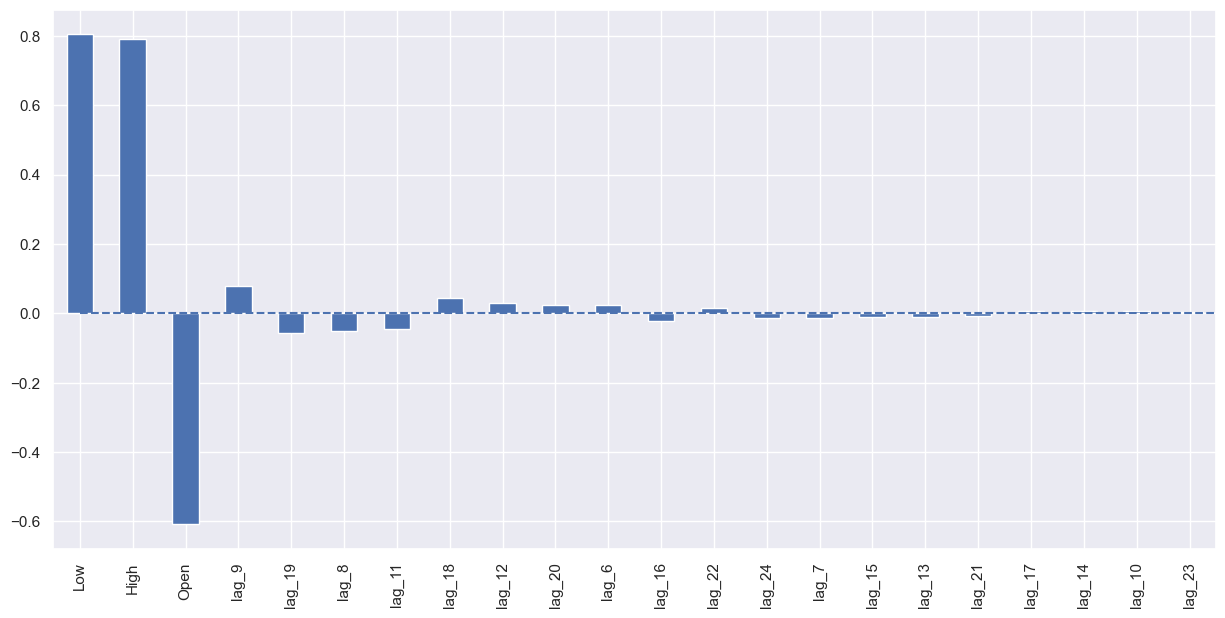

In [344]:
plotModelResults(lr, plot_intervals=True)
plotCoefficients(lr)

Получили MAPE = 0.62% Хороший результат. По графику также видим, что фактические данные и предсказанные почти совпадают, в пределах доверительных интервалов

Low, High, Open,  lag_9, lag_19, lag_8 и lag_11 - признаки с наибольшей корреляцией

Увеличим количество признаков.
Добавим в датасет час, день недели и выходной в качестве категориальных переменных. Для этого переводим имеющийся в датафрейме индекс в формат datetime, и извлекаем из него hour и weekday.

In [346]:
data.index = pd.to_datetime(data.index)
data["hour"] = data.index.hour
data["weekday"] = data.index.weekday
data['is_weekend'] = data.weekday.isin([5,6])*1
data.tail()

,Close,Open,High,Low,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,...,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,hour,weekday,is_weekend
Date,,,,,,,,,,,,,,,,,,,,,
2025-04-15,155.52,155.27,159.12,155.27,138.86,136.59,150.91,168.56,168.17,170.55,...,172.83,172.62,161.57,161.85,161.81,159.32,158.80,0,1,0
2025-04-16,156.47,154.37,157.66,153.54,139.39,138.86,136.59,150.91,168.56,168.17,...,178.11,172.83,172.62,161.57,161.85,161.81,159.32,0,2,0
2025-04-17,161.90,157.13,163.90,157.00,160.82,139.39,138.86,136.59,150.91,168.56,...,180.90,178.11,172.83,172.62,161.57,161.85,161.81,0,3,0
2025-04-21,159.34,162.40,160.00,156.47,155.52,160.82,139.39,138.86,136.59,150.91,...,182.59,180.90,178.11,172.83,172.62,161.57,161.85,0,0,0
2025-04-22,159.86,162.13,162.97,158.61,156.84,155.52,160.82,139.39,138.86,136.59,...,178.55,182.59,180.90,178.11,172.83,172.62,161.57,0,1,0


Визуализируем полученные признаки

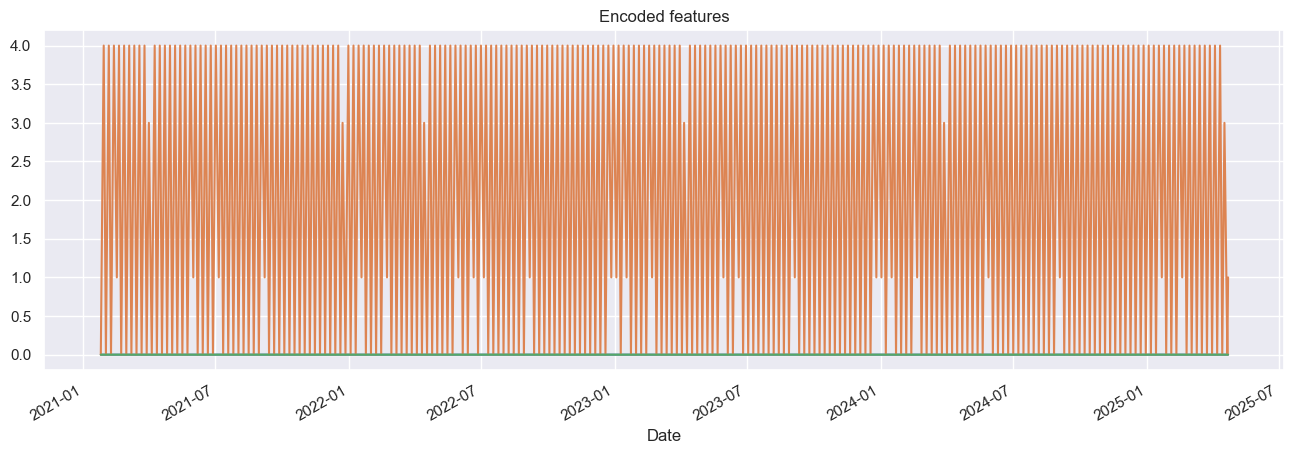

In [348]:
plt.figure(figsize=(16, 5))
plt.title("Encoded features")
data.hour.plot()
data.weekday.plot()
data.is_weekend.plot()
plt.grid(True);
plt.show()

Так как теперь у нас данные в разном масштабе - десятки тысяч в лагах и единицы в категориях, имеет смысл привести всё к одному масштабу, чтобы можно было по-прежнему исследовать коэффициенты модели. Для этого воспользуемся StandardScaler

In [ ]:
Так как мы работаем с линейной моделью, имеет смысл преобразовать категориальные переменные

In [350]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

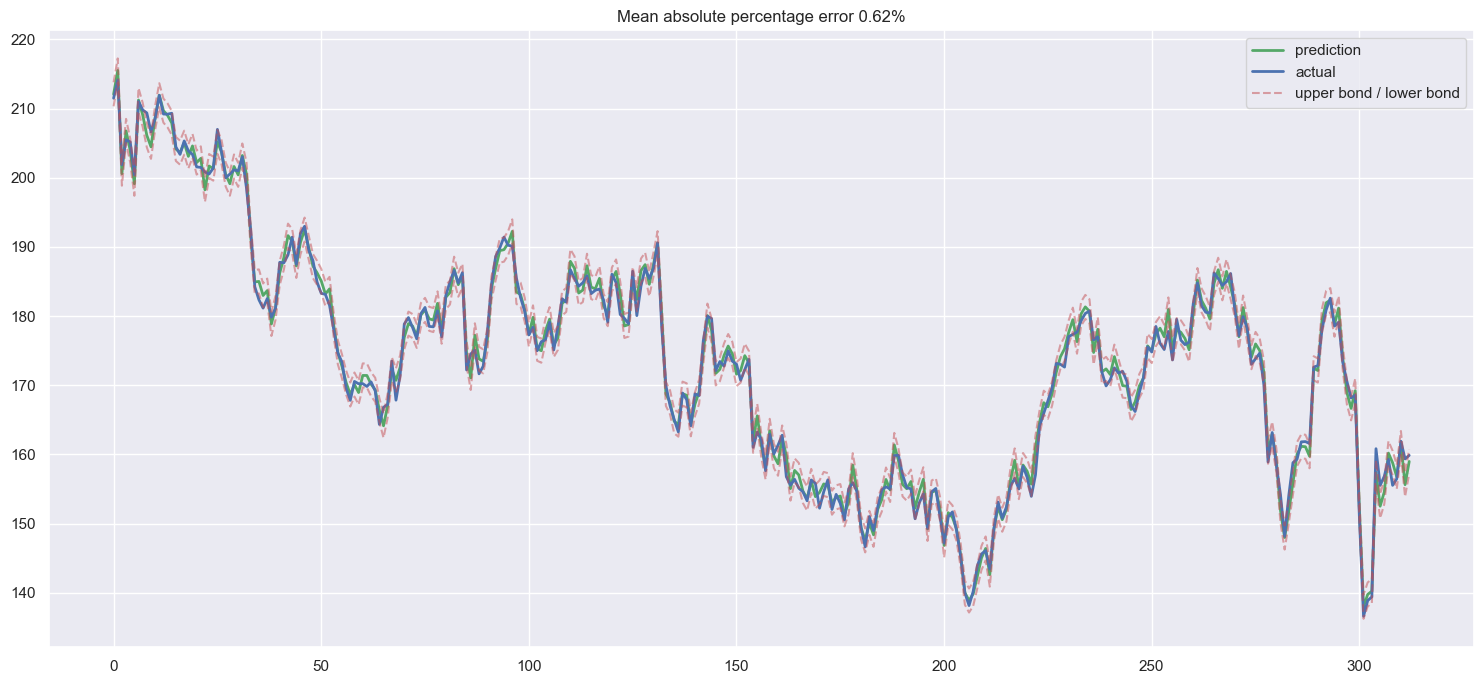

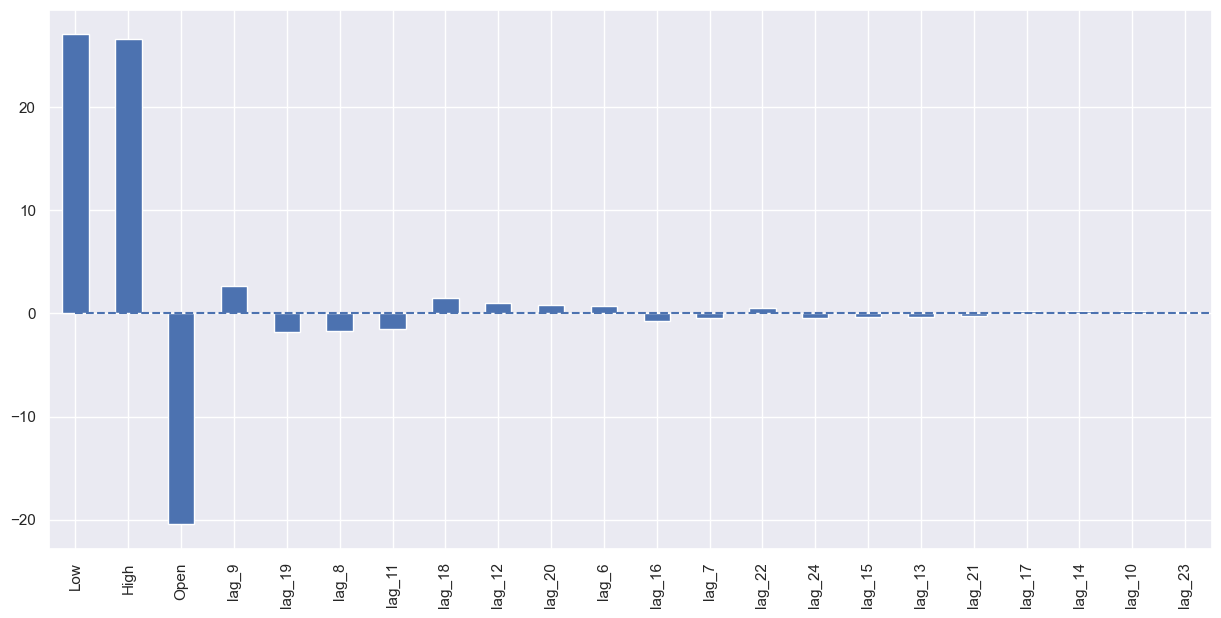

In [356]:
#y = data.dropna().CLose
#X = data.dropna().drop(['Close'], axis=1)

X_train, X_test, y_train, y_test = timeseries_train_test_split(X, y, test_size=0.3)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

plotModelResults(lr, X_train=X_train_scaled, X_test=X_test_scaled, plot_intervals=True)
plotCoefficients(lr)

In [ ]:
Добавление новых признаков не повлияла на прогноз. Значение MAPE не изменилось

Бустинг

In [ ]:
Проведем исследование с помощью модели - AdaBoostRegressor

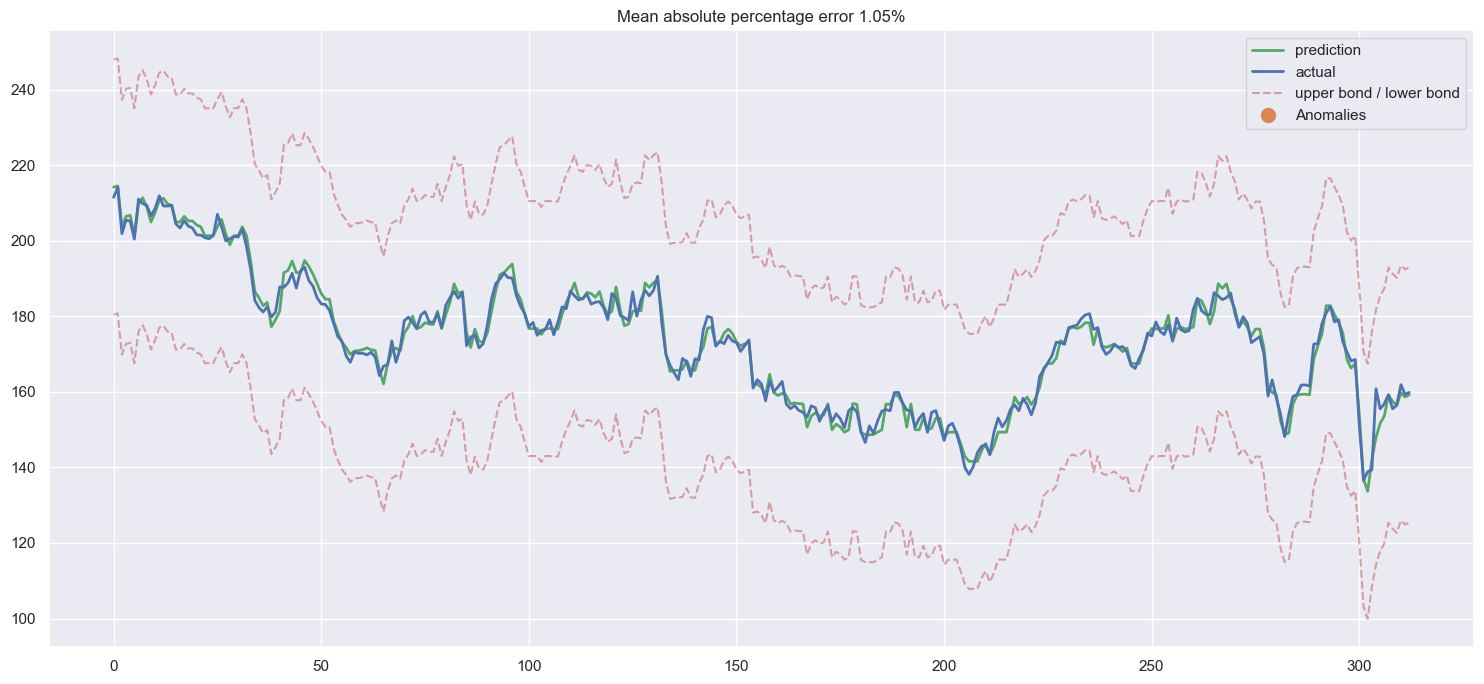

In [358]:
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor

gbr = AdaBoostRegressor(n_estimators=100)
gbr.fit(X_train_scaled, y_train)

plotModelResults(gbr, 
                 X_train=X_train_scaled, 
                 X_test=X_test_scaled, 
                 plot_intervals=True, plot_anomalies=True)

Получили MAPE = 1.05% Хороший результат. По графику также видим, что фактические данные и предсказанные почти совпадают, в пределах доверительных интервалов

Можно сделать вывод, что при прогнозировании с помощью линейной регрессии MAPE получили ниже (т.е. ошибка меньше), при анализе графика отличия также незначительные.